In [1]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models

from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer

pi = 3.14159265359

maxval=1e9
minval=1e-9

2025-07-22 18:38:50.248535: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-22 18:38:50.248600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-22 18:38:50.249746: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-22 18:38:50.256761: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-22 18:38:52.641315: W tensorflow/compiler/tf2

In [2]:
import keras
from keras.layers import *
from keras.models import Sequential, Model
from keras.utils import Sequence
from qkeras import *

import tensorflow as tf
from tensorflow.keras import datasets, layers, models

def var_network(var, hidden=10, output=2):
    var = Flatten()(var)
    var = QDense(
        hidden,
        kernel_quantizer=quantized_bits(8, 0, alpha=1),
        bias_quantizer=quantized_bits(8, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(8, 0, 1)")(var)
    var = QDense(
        hidden,
        kernel_quantizer=quantized_bits(8, 0, alpha=1),
        bias_quantizer=quantized_bits(8, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(8, 0, 1)")(var)
    return QDense(
        output,
        kernel_quantizer=quantized_bits(8, 0, alpha=1),
        bias_quantizer=quantized_bits(8, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
    )(var)

def conv_network(var, n_filters=5, kernel_size=3):
    var = QSeparableConv2D(
        n_filters,kernel_size,
        depthwise_quantizer=quantized_bits(4, 0, 1, alpha=1),
        pointwise_quantizer=quantized_bits(4, 0, 1, alpha=1),
        bias_quantizer=quantized_bits(4, 0, alpha=1),
        depthwise_regularizer=tf.keras.regularizers.L1L2(0.01),
        pointwise_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(4, 0, 1)")(var)
    var = QConv2D(
        n_filters,1,
        kernel_quantizer=quantized_bits(4, 0, alpha=1),
        bias_quantizer=quantized_bits(4, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(4, 0, 1)")(var)    
    return var

def CreateModel(shape, output, n_filters, pool_size):
    x_base = x_in = Input(shape)
    x_base = SoftQuantizeLayer(
        n_bits=2,                     
        initial_range=[-1.0, 1.0],    
        trainable_levels=False,        
        trainable_bins=True,          
        initial_k=1.0,                
        trainable_k=True,             
        name='soft_quantizer_output'  
    )(x_base)

    stack = conv_network(x_base)
    stack = AveragePooling2D(
        pool_size=(pool_size, pool_size), 
        strides=None, 
        padding="valid", 
        data_format=None,        
    )(stack)
    stack = QActivation("quantized_bits(8, 0, alpha=1)")(stack)
    stack = var_network(stack, hidden=16, output=output)
    model = Model(inputs=x_in, outputs=stack)
    return model

In [3]:
model=CreateModel(shape = (16,16,2), output = 14, n_filters=5,pool_size=3)
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

model.summary()

2025-07-22 18:39:01.047326: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1755 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB MIG 7g.40gb, pci bus id: 0000:21:00.0, compute capability: 8.0
2025-07-22 18:39:01.280652: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 16, 16, 2)]       0         
                                                                 
 soft_quantizer_output (Sof  (None, 16, 16, 2)         9         
 tQuantizeLayer)                                                 
                                                                 
 q_separable_conv2d (QSepar  (None, 14, 14, 5)         33        
 ableConv2D)                                                     
                                                                 
 q_activation (QActivation)  (None, 14, 14, 5)         0         
                                                                 
 q_conv2d (QConv2D)          (None, 14, 14, 5)         30        
                                                                 
 q_activation_1 (QActivatio  (None, 14, 14, 5)         0     

In [4]:
fingerprint = "41166c06"
# model-6fe6ea98-checkpoints
# 8b72d007: Variable x-bin and y-hieghts

In [5]:
base_dir = f'./trained_models/model-{fingerprint}-checkpoints'
plot_dir = os.path.join(base_dir, 'plots')
checkpoints_dir = os.path.join(base_dir, 'checkpoints')
training_cp_path = os.path.join(base_dir, 'training_log.csv')
training_history = pd.read_csv(training_cp_path)

os.makedirs(plot_dir, exist_ok=True)

checkpoint_files = sorted([os.path.join(checkpoints_dir, f) for f in os.listdir(checkpoints_dir) if f.endswith('.hdf5')])
checkpoint_files

['./trained_models/model-41166c06-checkpoints/checkpoints/weights.01-t47219.01-v16182.26.hdf5',
 './trained_models/model-41166c06-checkpoints/checkpoints/weights.02-t13870.87-v12290.01.hdf5',
 './trained_models/model-41166c06-checkpoints/checkpoints/weights.03-t20665.34-v12692.29.hdf5',
 './trained_models/model-41166c06-checkpoints/checkpoints/weights.04-t17453.56-v102853.21.hdf5',
 './trained_models/model-41166c06-checkpoints/checkpoints/weights.05-t9954.73-v7096.44.hdf5',
 './trained_models/model-41166c06-checkpoints/checkpoints/weights.06-t12696.38-v7228.73.hdf5',
 './trained_models/model-41166c06-checkpoints/checkpoints/weights.07-t8152.24-v8086.72.hdf5',
 './trained_models/model-41166c06-checkpoints/checkpoints/weights.08-t6659.79-v4066.55.hdf5',
 './trained_models/model-41166c06-checkpoints/checkpoints/weights.09-t5655.84-v6748.43.hdf5',
 './trained_models/model-41166c06-checkpoints/checkpoints/weights.10-t4684.77-v3130.75.hdf5',
 './trained_models/model-41166c06-checkpoints/chec

In [6]:
def extract_val_metric(fname):
    try:
        val_str = fname.split("-v-")[-1].replace(".hdf5", "")
        return float(val_str)
    except Exception:
        return float("-inf")

best_ckpt = None
best_val = float("-inf")

for f in checkpoint_files:
    val = extract_val_metric(os.path.basename(f))
    if val > best_val:
        best_val = val
        best_ckpt = f

print(f"Loading model from {best_ckpt}")
model.load_weights(best_ckpt)

Loading model from ./trained_models/model-41166c06-checkpoints/checkpoints/weights.748-t-23093.36-v-24317.21.hdf5


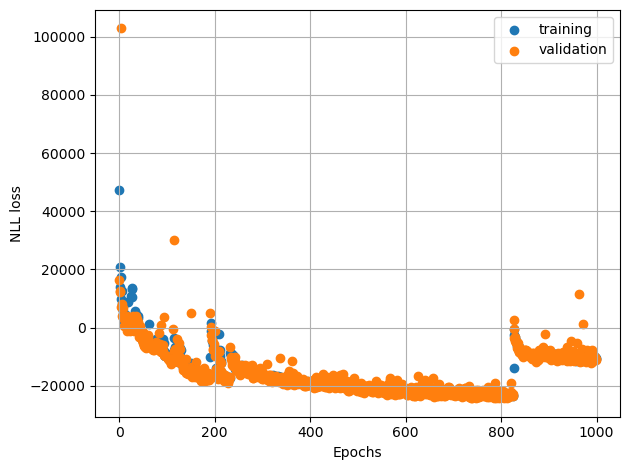

In [7]:
plt.scatter(training_history['epoch'], training_history['loss'])
plt.scatter(training_history['epoch'], training_history['val_loss'])
plt.legend(['training', 'validation'])
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('NLL loss')
plt.tight_layout() 

plt.savefig(os.path.join(base_dir,'training_hist.png'))
plt.show()

Current k: [56.771416]
sq_layer: tf.Tensor([-1.         -0.3333333   0.33333337  1.        ], shape=(4,), dtype=float32)
sq_layer tf.Tensor([-0.8506823  -0.40504652 -0.40497828  0.49032193], shape=(4,), dtype=float32)


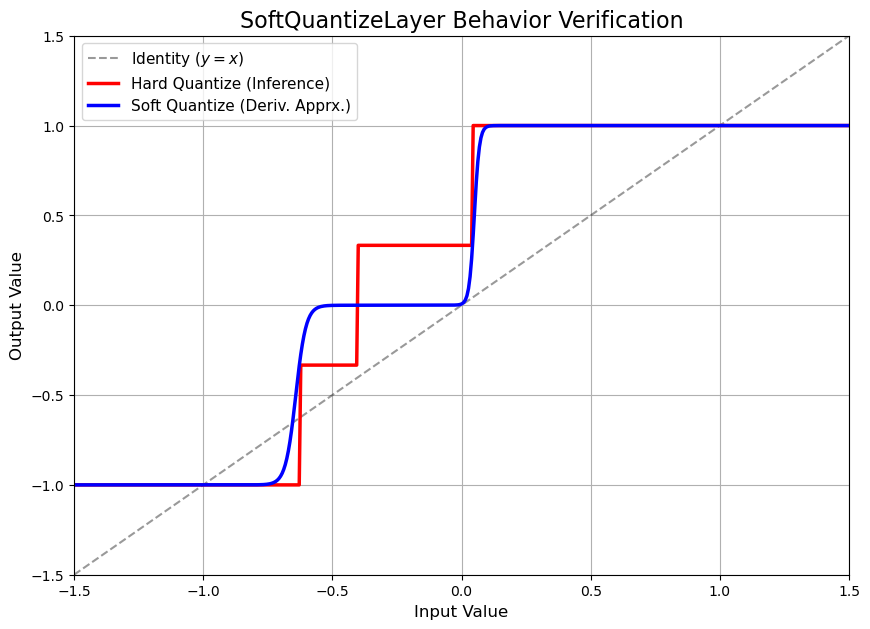

In [14]:
sq_layer = model.get_layer(name="soft_quantizer_output")
print("Current k:", sq_layer.k.numpy())
print("sq_layer:", sq_layer.levels)
print("sq_layer", sq_layer.bin_centers)

x_input = tf.constant(np.linspace(-1.5, 1.5, 500), dtype=tf.float32)
initial_first_level = sq_layer.first_level.numpy()[0]
initial_level_deltas = tf.exp(sq_layer.log_level_deltas).numpy()
initial_first_bin = sq_layer.first_bin_center.numpy()[0]
initial_bin_deltas = tf.exp(sq_layer.log_bin_deltas).numpy()

y_hard = sq_layer._hard_quantize(x_input, sq_layer.levels, sq_layer.bin_centers)
y_soft = sq_layer._soft_quantize(x_input, sq_layer.levels, sq_layer.bin_centers)

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(x_input, x_input, 'k--', alpha=0.4, label='Identity ($y=x$)')
ax.plot(x_input, y_hard, color='red', linewidth=2.5, label=f'Hard Quantize (Inference)')
ax.plot(x_input, y_soft, 'blue', linestyle='-', linewidth=2.5, label=f'Soft Quantize (Deriv. Apprx.)')

ax.set_title("SoftQuantizeLayer Behavior Verification", fontsize=16)
ax.set_xlabel("Input Value", fontsize=12)
ax.set_ylabel("Output Value", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

plt.show()

In [15]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/contained"
tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")


In [16]:
test_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=True,
)
labels_scale = test_generator.labels_scale
print(labels_scale)

Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/contained/TFR_files/2t/TFR_val/metadata.json
[99.17029747 24.79370923  6.53245764  1.89031215]


In [17]:
# predicts test data
p_test = model.predict(test_generator)

 4/21 [====>.........................] - ETA: 0s

2025-07-22 18:47:20.680788: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


21/21 [==============================] - 2s 72ms/step


In [18]:
complete_truth = None
for _, y in tqdm(test_generator):
        if complete_truth is None:
            complete_truth = y
        else:
            complete_truth = np.concatenate((complete_truth, y), axis=0)

100%|██████████| 21/21 [00:01<00:00, 15.48it/s]


In [19]:
def softplus(x):
    x = np.asarray(x)
    return np.maximum(x, 0) + np.log1p(np.exp(-np.abs(x)))

In [20]:
# creates df with all predicted values and matrix elements - 4 predictions, all 10 unique matrix elements
df = pd.DataFrame(p_test,columns=['x','M11','y','M22','cotA','M33','cotB','M44','M21','M31','M32','M41','M42','M43'])

# stores all true values in same matrix as xtrue, ytrue, etc.
df['xtrue'] = complete_truth[:,0]
df['ytrue'] = complete_truth[:,1]
df['cotAtrue'] = complete_truth[:,2]
df['cotBtrue'] = complete_truth[:,3]
df['M11'] = minval+tf.math.maximum(df['M11'], 0)
df['M22'] = minval+tf.math.maximum(df['M22'], 0)
df['M33'] = minval+tf.math.maximum(df['M33'], 0)
df['M44'] = minval+tf.math.maximum(df['M44'], 0)

df['sigmax'] = abs(df['M11'])
df['sigmay'] = np.sqrt(df['M21']**2 + df['M22']**2)
df['sigmacotA'] = np.sqrt(df['M31']**2+df['M32']**2+df['M33']**2)
df['sigmacotB'] = np.sqrt(df['M41']**2+df['M42']**2+df['M43']**2+df['M44']**2)

# calculates residuals for x, y, cotA, cotB
residuals = df['xtrue'] - df['x']
residualsy = df['ytrue'] - df['y']
residualsA = df['cotAtrue'] - df['cotA']
residualsB = df['cotBtrue'] - df['cotB']

# stores results as csv
df.to_csv("test_4x4.csv",header=True,index=False)

# residuals (mean, stdv)

In [21]:
# x
(np.mean(residuals)*labels_scale[0],np.std(residuals)*labels_scale[0])

(0.03559462082190026, 12.355550717504967)

In [22]:
# y
(np.mean(residualsy)*labels_scale[1],np.std(residualsy)*labels_scale[1])

(0.23713565246216856, 3.3168060567267768)

In [23]:
# cotA
(np.mean(residualsA)*labels_scale[2],np.std(residualsA)*labels_scale[2])

(0.010704851029613485, 0.3938359908327923)

In [24]:
# cotB
(np.mean(residualsB)*labels_scale[3],np.std(residualsB)*labels_scale[3])

(0.010664550730298632, 0.1192587166647817)

# x residuals

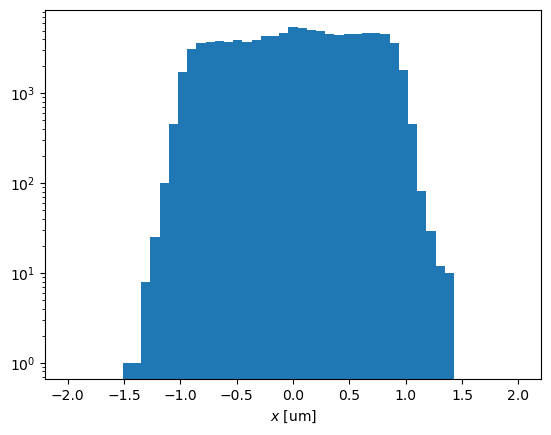

In [25]:
plt.hist(p_test[:,0],bins=np.linspace(-2,2,50))
plt.yscale('log')
plt.xlabel(r'$x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_dist.png')
plt.savefig(save_fig_path)

plt.show()

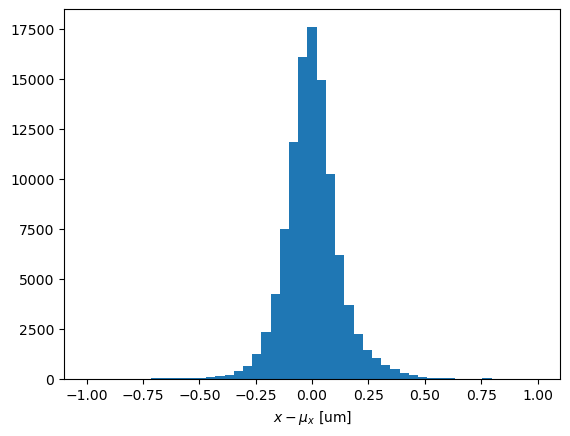

In [26]:
plt.hist(residuals,bins=np.linspace(-1,1,50))
#plt.yscale('Log')
plt.xlabel(r'$x-\mu_x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

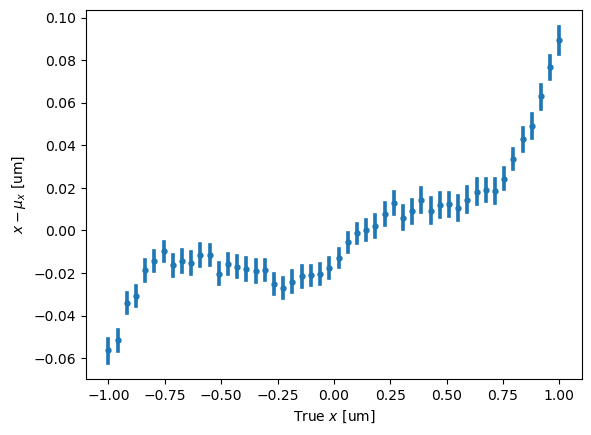

In [27]:
x = sns.regplot(x=df['xtrue'], y=(df['xtrue']-df['x']), x_bins=np.linspace(-1,1,50), fit_reg=None, marker='.')
plt.xlabel(r'True $x$ [um]')
plt.ylabel(r'$x-\mu_x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# y residuals

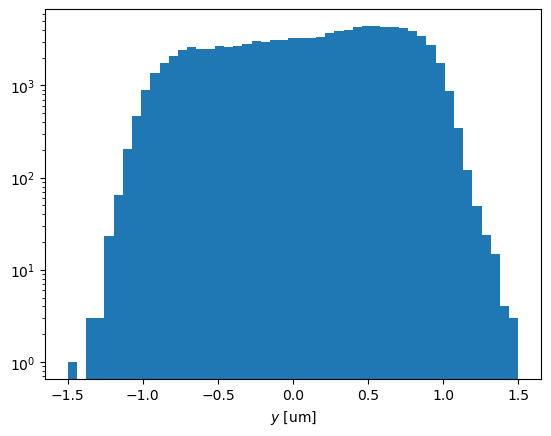

In [28]:
plt.hist(p_test[:,2],bins=np.linspace(-1.5,1.5,50))
plt.yscale('log')
plt.xlabel(r'$y$ [um]')

save_fig_path = os.path.join(plot_dir, 'y_dist.png')
plt.savefig(save_fig_path)

plt.show()

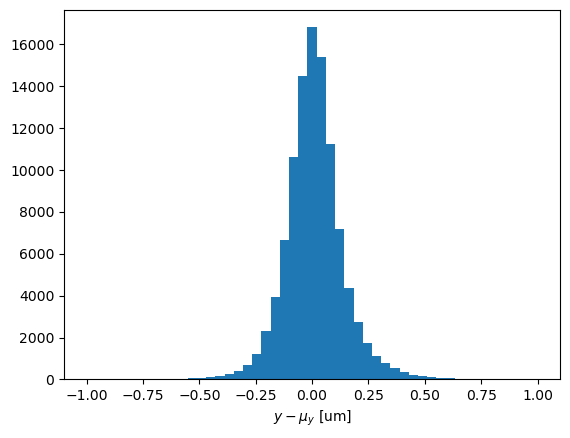

In [29]:
plt.hist(residualsy,bins=np.linspace(-1,1,50))
#plt.yscale('Log')
plt.xlabel(r'$y-\mu_y$ [um]')

save_fig_path = os.path.join(plot_dir, 'y_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

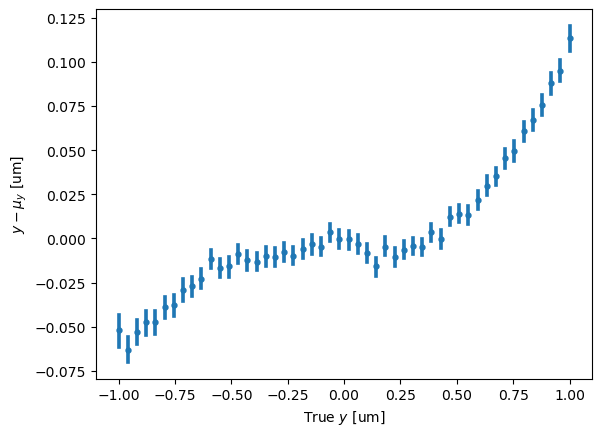

In [30]:
x = sns.regplot(x=df['ytrue'], y=(df['ytrue']-df['y']), x_bins=np.linspace(-1,1,50), fit_reg=None, marker='.')
plt.xlabel(r'True $y$ [um]')
plt.ylabel(r'$y-\mu_y$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# cotA residuals

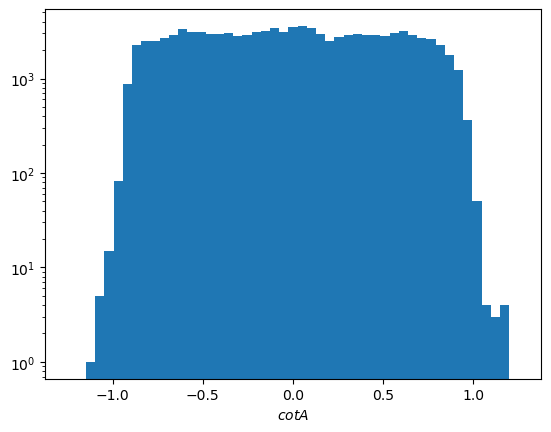

In [31]:
plt.hist(df["cotA"],bins=np.linspace(-1.25,1.25,50))
plt.yscale('log')
plt.xlabel(r'$cotA$')

save_fig_path = os.path.join(plot_dir, 'cotA_dist.png')
plt.savefig(save_fig_path)

plt.show()

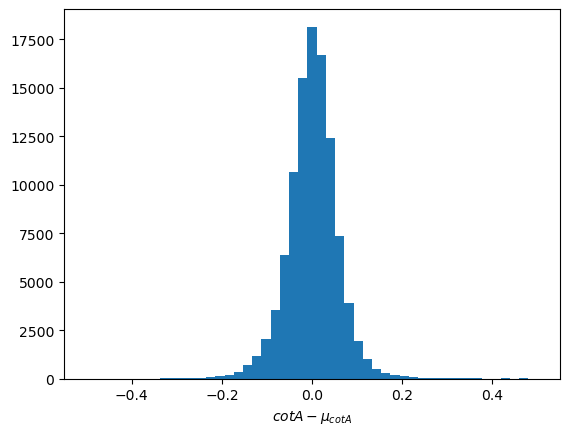

In [32]:
plt.hist(residualsA,bins=np.linspace(-0.5,0.5,50))
#plt.yscale('Log')
plt.xlabel(r'$cotA-\mu_{cotA}$')

save_fig_path = os.path.join(plot_dir, 'cotA_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

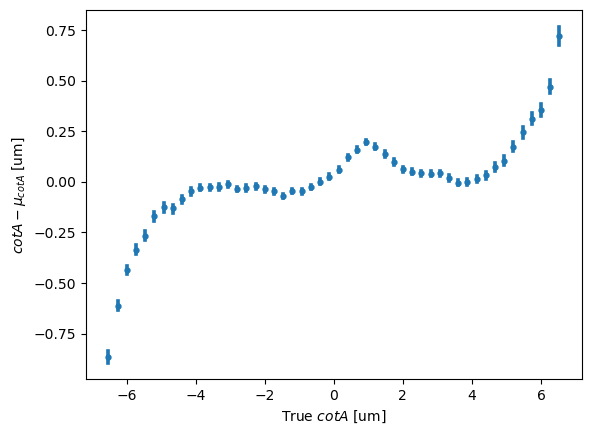

In [33]:
x = sns.regplot(x=df['cotAtrue']*labels_scale[2], y=(df['cotAtrue']-df['cotA'])*labels_scale[2], x_bins=np.linspace(-labels_scale[2],labels_scale[2],50), fit_reg=None, marker='.')
plt.xlabel(r'True $cotA$ [um]')
plt.ylabel(r'$cotA-\mu_{cotA}$ [um]')

save_fig_path = os.path.join(plot_dir, 'cotA_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# cotB residuals

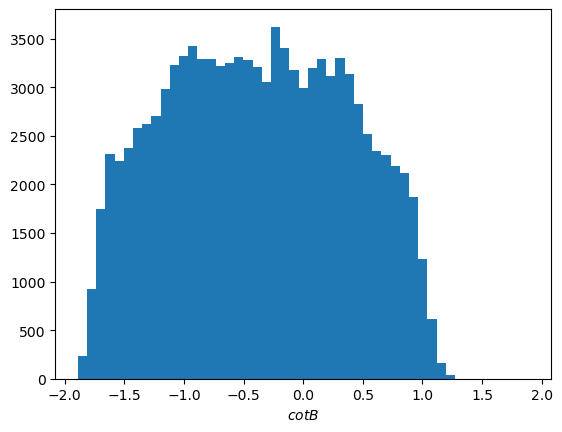

In [34]:
plt.hist(df["cotB"]*labels_scale[3],bins=np.linspace(-labels_scale[3],labels_scale[3],50))
#plt.yscale('Log')
plt.xlabel(r'$cotB$')

save_fig_path = os.path.join(plot_dir, 'cotB_dist.png')
plt.savefig(save_fig_path)

plt.show()

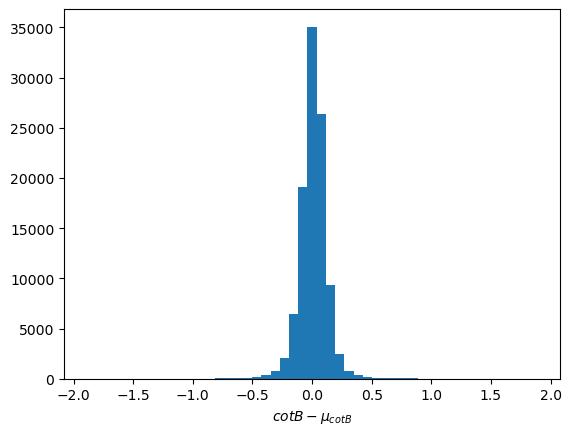

In [35]:
plt.hist(residualsB*labels_scale[3],bins=np.linspace(-labels_scale[3],labels_scale[3],50))
#plt.yscale('Log')
plt.xlabel(r'$cotB-\mu_{cotB}$')

save_fig_path = os.path.join(plot_dir, 'cotB_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

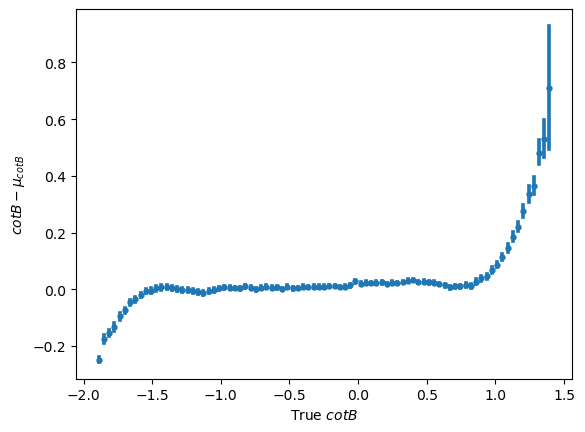

In [36]:
x = sns.regplot(x=df['cotBtrue']*labels_scale[3], y=(df['cotBtrue']-df['cotB'])*labels_scale[3], x_bins=np.linspace(-labels_scale[3],labels_scale[3],100), fit_reg=None, marker='.')
plt.xlabel(r'True $cotB$')
plt.ylabel(r'$cotB-\mu_{cotB} $')

save_fig_path = os.path.join(plot_dir, 'cotB_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# pull

In [37]:
df['pullx'] = (df['xtrue']-df['x'])/df['sigmax']
df['pully'] = (df['ytrue']-df['y'])/df['sigmay']
df['pullcotA'] = (df['cotAtrue']-df['cotA'])/df['sigmacotA']
df['pullcotB'] = (df['cotBtrue']-df['cotB'])/df['sigmacotB']

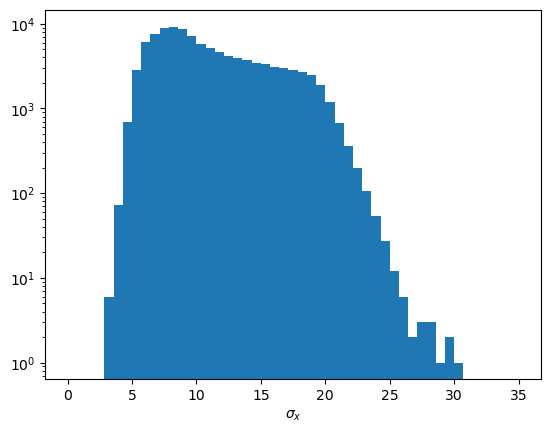

In [38]:
plt.hist(df['sigmax'] *labels_scale[0],bins=np.linspace(0,35,50))
plt.xlabel('$\sigma_{x}$')
plt.yscale('log')

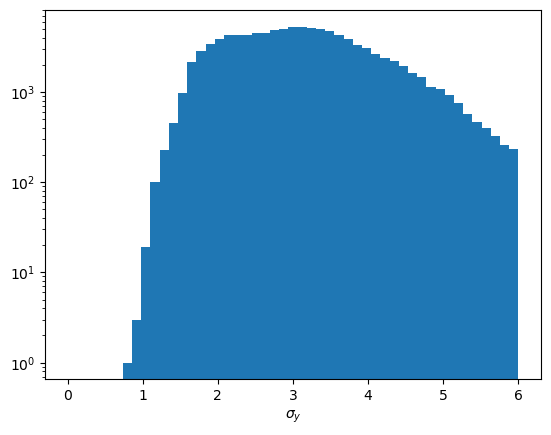

In [39]:
plt.hist(df['sigmay']*labels_scale[1],bins=np.linspace(0,6,50))
plt.xlabel('$\sigma_{y}$')
plt.yscale('log')

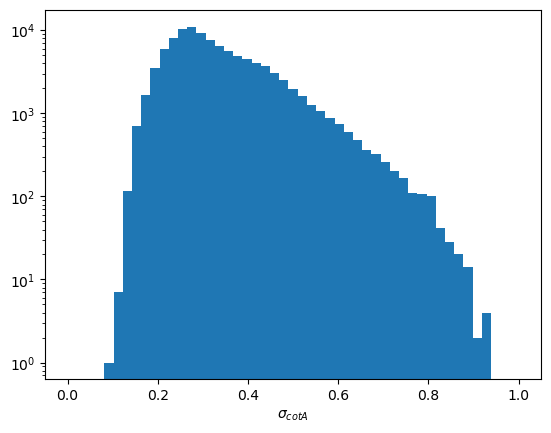

In [40]:
plt.hist(df['sigmacotA'] *labels_scale[2],bins=np.linspace(0,1.0,50))
plt.xlabel('$\sigma_{cotA}$')
plt.yscale('log')

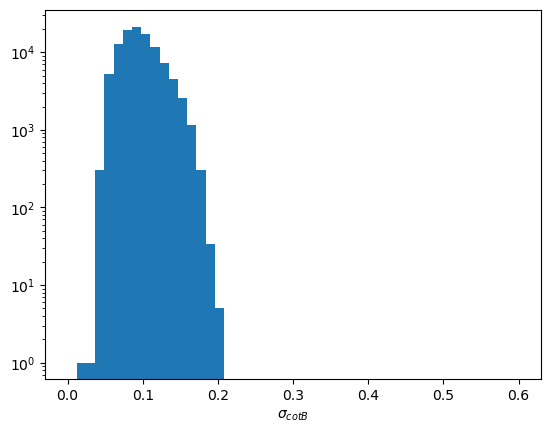

In [41]:
plt.hist(df['sigmacotB'] *labels_scale[3] ,bins=np.linspace(0,0.6,50))
plt.xlabel('$\sigma_{cotB}$')
plt.yscale('log')

In [42]:
from scipy.optimize import curve_fit

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def pull_plot(ax, var, name):
    
    h = ax.hist(df[var],bins=np.linspace(-5,5,50),histtype='step')
    ax.set_xlabel(name)
    ax.set_yscale('log')

    ydata = h[0]
    xdata = h[1][:-1]+3/50.

    pars, cov = curve_fit(gauss,xdata,ydata)

    xbins = np.linspace(-5,5,100)
    ax.plot(xbins,gauss(xbins,pars[0],pars[1],pars[2]),color='black')
    ax.set_ylim(0.5,100000)

    print('Mean',pars[1])
    print('Sigma',pars[2])
    
    ax.text(-5,2000,"$\mu$="+str(round(pars[1],2)))
    ax.text(-5,1000,"$\sigma$="+str(round(abs(pars[2]),2)))

Mean -0.08279292155486673
Sigma 0.9522726183308851
Mean 0.009948494660684494
Sigma 0.8631957846617055
Mean 0.00047225034428787475
Sigma 0.954684513329073
Mean 0.1059519623642159
Sigma 0.9334035159598111


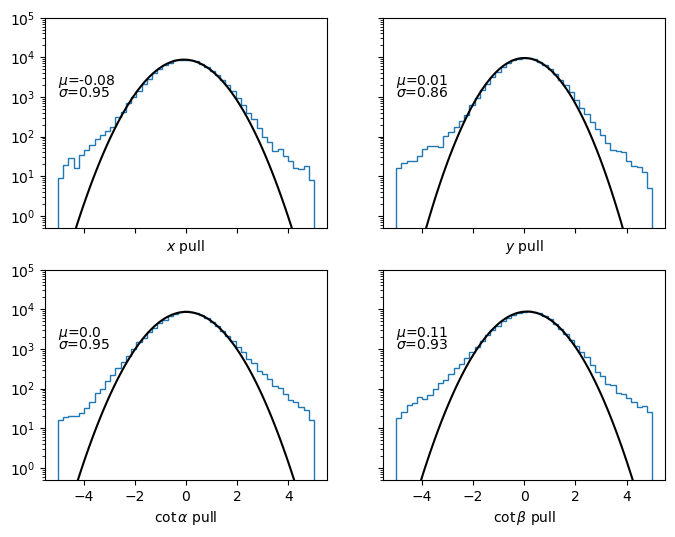

In [43]:
fig, axes = plt.subplots(2,2,sharex=True,sharey=True,figsize=(8,6))
pull_plot(axes[0][0],'pullx',r'$x$ pull')
pull_plot(axes[0][1],'pully',r'$y$ pull')
pull_plot(axes[1][0],'pullcotA',r'$\cot\alpha$ pull')
pull_plot(axes[1][1],'pullcotB',r'$\cot\beta$ pull')

save_fig_path = os.path.join(plot_dir, 'Pull.png')
plt.savefig(save_fig_path)

plt.show()

In [44]:
def residual_plot(ax, thisdf, var1, var2, name, scaling=1.0):
    
    nbins = 15
    
    var1_scaled = thisdf[var1] * scaling
    var2_scaled = thisdf[var2] * scaling
    residual_scaled = var1_scaled - var2_scaled
    
    xmin = np.min(var1_scaled)
    xmax = np.max(var1_scaled)
    
    step = 1.0*(xmax-xmin)/nbins
    
    x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = residual_scaled
    print(var1)
    
    means = []
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
        downbar += [means[i] - np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

def inverse_cot(cota):
    a = np.arctan(1.0/cota)
    a[np.where(a<0)] = a[np.where(a<0)] + pi
    return a    

def residual_plot_deg(ax, thisdf, var1, var2, name, scaling=1.0):
    # positions
    if 'cot' not in var1:
        residual_plot(ax, thisdf, var1, var2, name, scaling=scaling)
        return

    thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling)*180/pi
    
    thisdf['angleup'] = abs(inverse_cot((thisdf[var2].values + thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angledown'] = abs(inverse_cot((thisdf[var2].values - thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling)*180/pi
        
    var1 = 'angletrue'
    var2 = 'angle'
    
    nbins = 15
    xmin = np.min(thisdf[var1])
    xmax = np.max(thisdf[var1])
    
    step = 1.0*(xmax-xmin)/nbins
        
    x = sns.regplot(x=thisdf[var1], y=(thisdf[var1]-thisdf[var2]), x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = (thisdf[var1]-thisdf[var2])
    print(var1)
    
    means = []    
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['angleup'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        downbar += [means[i] - np.mean(thisdf['angledown'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
    #ax.scatter(x=np.linspace(xmin,xmax,nbins),y=means)
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

xtrue
ytrue


/tmp/ipykernel_396397/2844183014.py:31: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


/tmp/ipykernel_396397/2844183014.py:31: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


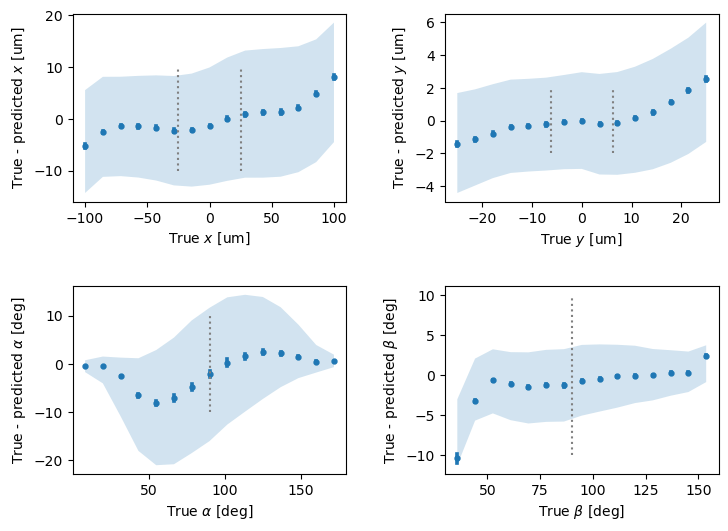

In [45]:
fig, axes = plt.subplots(2,2,figsize=(8,6))
fig.tight_layout(pad=4.0)
residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]', scaling=labels_scale[0])
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]', scaling=labels_scale[1])
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df,'cotAtrue','cotA',r'$\alpha$ [deg]', scaling=labels_scale[2])
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df,'cotBtrue','cotB',r'$\beta$ [deg]', scaling=labels_scale[3])
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')

save_fig_path = os.path.join(plot_dir, 'summary.png')
plt.savefig(save_fig_path)